In [1]:
!pip install -q transformers datasets accelerate bitsandbytes sentencepiece
!pip install -q matplotlib seaborn scikit-learn nltk
!pip install -q bert-score rouge_score sentence-transformers faiss-cpu rank_bm25
!pip install -q xgboost lightgbm optuna shap wordcloud plotly
!pip install -q torch torchvision
print('✅ All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 77.3 MB/s eta 0:00:00:00:0100:01
✅ All packages installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn as nn
import re, warnings, os
import shap
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from wordcloud import WordCloud

import faiss
from transformers import (
    pipeline, AutoModelForCausalLM, AutoTokenizer,
    BitsAndBytesConfig
)
from sentence_transformers import SentenceTransformer
from datasets import load_dataset
from bert_score import score as bert_score
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rank_bm25 import BM25Okapi

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    classification_report, average_precision_score, matthews_corrcoef
)
from sklearn.calibration import CalibrationDisplay
from sklearn.inspection import permutation_importance
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"}')

# ── Plotting globals ──
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
DARK_BG = '#1a1a2e'

Device: cuda
GPU: Tesla T4


In [3]:
BASE_PATH = "/kaggle/input/datasets/montassarba/mimic-iv-clinical-database-demo-2-2/mimic-iv-clinical-database-demo-2.2"
B2 = "/kaggle/input/datasets/asjad99/mimiciii/mimic-iii-clinical-database-demo-1.4"

patients    = pd.read_csv(f"{BASE_PATH}/hosp/patients.csv")
admissions  = pd.read_csv(f"{BASE_PATH}/hosp/admissions.csv")
labevents   = pd.read_csv(f"{BASE_PATH}/hosp/labevents.csv")
icustays    = pd.read_csv(f"{BASE_PATH}/icu/icustays.csv")
chartevents = pd.read_csv(f"{BASE_PATH}/icu/chartevents.csv")
notes       = pd.read_csv(f"{B2}/NOTEEVENTS.csv")

print(f'Patients: {patients.shape}, Admissions: {admissions.shape}')
print(f'Labevents: {labevents.shape}, ICU stays: {icustays.shape}')
print(f'Notes: {notes.shape}')
patients.head(3)

Patients: (100, 6), Admissions: (275, 16)
Labevents: (107727, 16), ICU stays: (140, 8)
Notes: (0, 11)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN


In [4]:
# ── Merge core tables ──
df = admissions.merge(patients, on='subject_id')
df = df.merge(icustays, on=['subject_id', 'hadm_id'], how='left')

# ── Time features ──
for col in ['admittime', 'dischtime']:
    df[col] = pd.to_datetime(df[col])

df['los_hours']      = (df['dischtime'] - df['admittime']).dt.total_seconds() / 3600
df['admit_hour']     = df['admittime'].dt.hour
df['admit_dayofweek']= df['admittime'].dt.dayofweek
df['admit_month']    = df['admittime'].dt.month
df['is_weekend']     = (df['admit_dayofweek'] >= 5).astype(int)

# ── Demographics ──
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

# Encode admission type
if 'admission_type' in df.columns:
    le = LabelEncoder()
    df['admission_type_enc'] = le.fit_transform(df['admission_type'].fillna('UNKNOWN'))

# ── Lab aggregations ──
lab_agg = labevents.groupby('subject_id').agg(
    lab_mean=('valuenum', 'mean'),
    lab_max=('valuenum', 'max'),
    lab_min=('valuenum', 'min'),
    lab_std=('valuenum', 'std'),
    lab_count=('valuenum', 'count'),
    lab_range=('valuenum', lambda x: x.max() - x.min())
).reset_index()

df = df.merge(lab_agg, on='subject_id', how='left')

# ── ICU features ──
if 'los_x' in df.columns:
    df['icu_los'] = df['los_x']
elif 'los' in df.columns:
    df['icu_los'] = df['los']
else:
    df['icu_los'] = 0.0

# ── Target ──
df['target'] = df['hospital_expire_flag'].astype(int)

# ── Final feature set ──
FEATURES = [
    'anchor_age', 'los_hours', 'gender',
    'lab_mean', 'lab_max', 'lab_min', 'lab_std', 'lab_range', 'lab_count',
    'icu_los', 'admit_hour', 'admit_dayofweek', 'admit_month', 'is_weekend'
]
if 'admission_type_enc' in df.columns:
    FEATURES.append('admission_type_enc')

df = df.fillna(df.median(numeric_only=True))

print(f'Final dataframe shape: {df.shape}')
print(f'Target distribution:\n{df["target"].value_counts()}')
df[FEATURES + ['target']].describe()

Final dataframe shape: (287, 41)
Target distribution:
target
0    267
1     20
Name: count, dtype: int64


,anchor_age,los_hours,gender,lab_mean,lab_max,lab_min,lab_std,lab_range,lab_count,icu_los,admit_hour,admit_dayofweek,admit_month,is_weekend,admission_type_enc,target
count,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000
mean,61.219512,179.084959,0.522648,68.140617,15495.480836,-106.471707,469.354651,15601.952544,2301.954704,2.898647,13.526132,3.006969,6.714286,0.303136,5.163763,0.069686
std,14.363314,187.928989,0.500359,51.903067,24443.096961,222.274818,743.365321,24454.420939,2605.226771,2.821525,7.405714,2.032933,3.338990,0.460416,1.898935,0.255063
min,21.000000,1.116667,0.000000,21.831483,158.000000,-780.000000,47.863862,158.000000,64.000000,0.023727,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,53.000000,65.358333,0.000000,47.077111,938.000000,-14.000000,85.825569,970.500000,477.000000,2.155093,7.000000,1.000000,4.000000,0.000000,5.000000,0.000000
50%,60.000000,121.316667,1.000000,52.725238,3643.000000,-6.000000,163.523668,3644.000000,1192.000000,2.155093,15.000000,3.000000,7.000000,0.000000,5.000000,0.000000
75%,70.000000,222.383333,1.000000,65.170809,25105.000000,-1.000000,555.314007,25111.000000,2789.000000,2.155093,20.000000,5.000000,10.000000,1.000000,6.000000,0.000000
max,91.000000,1078.266667,1.000000,589.833281,169000.000000,0.400000,4656.196553,169025.000000,8937.000000,20.528681,23.000000,6.000000,12.000000,1.000000,8.000000,1.000000


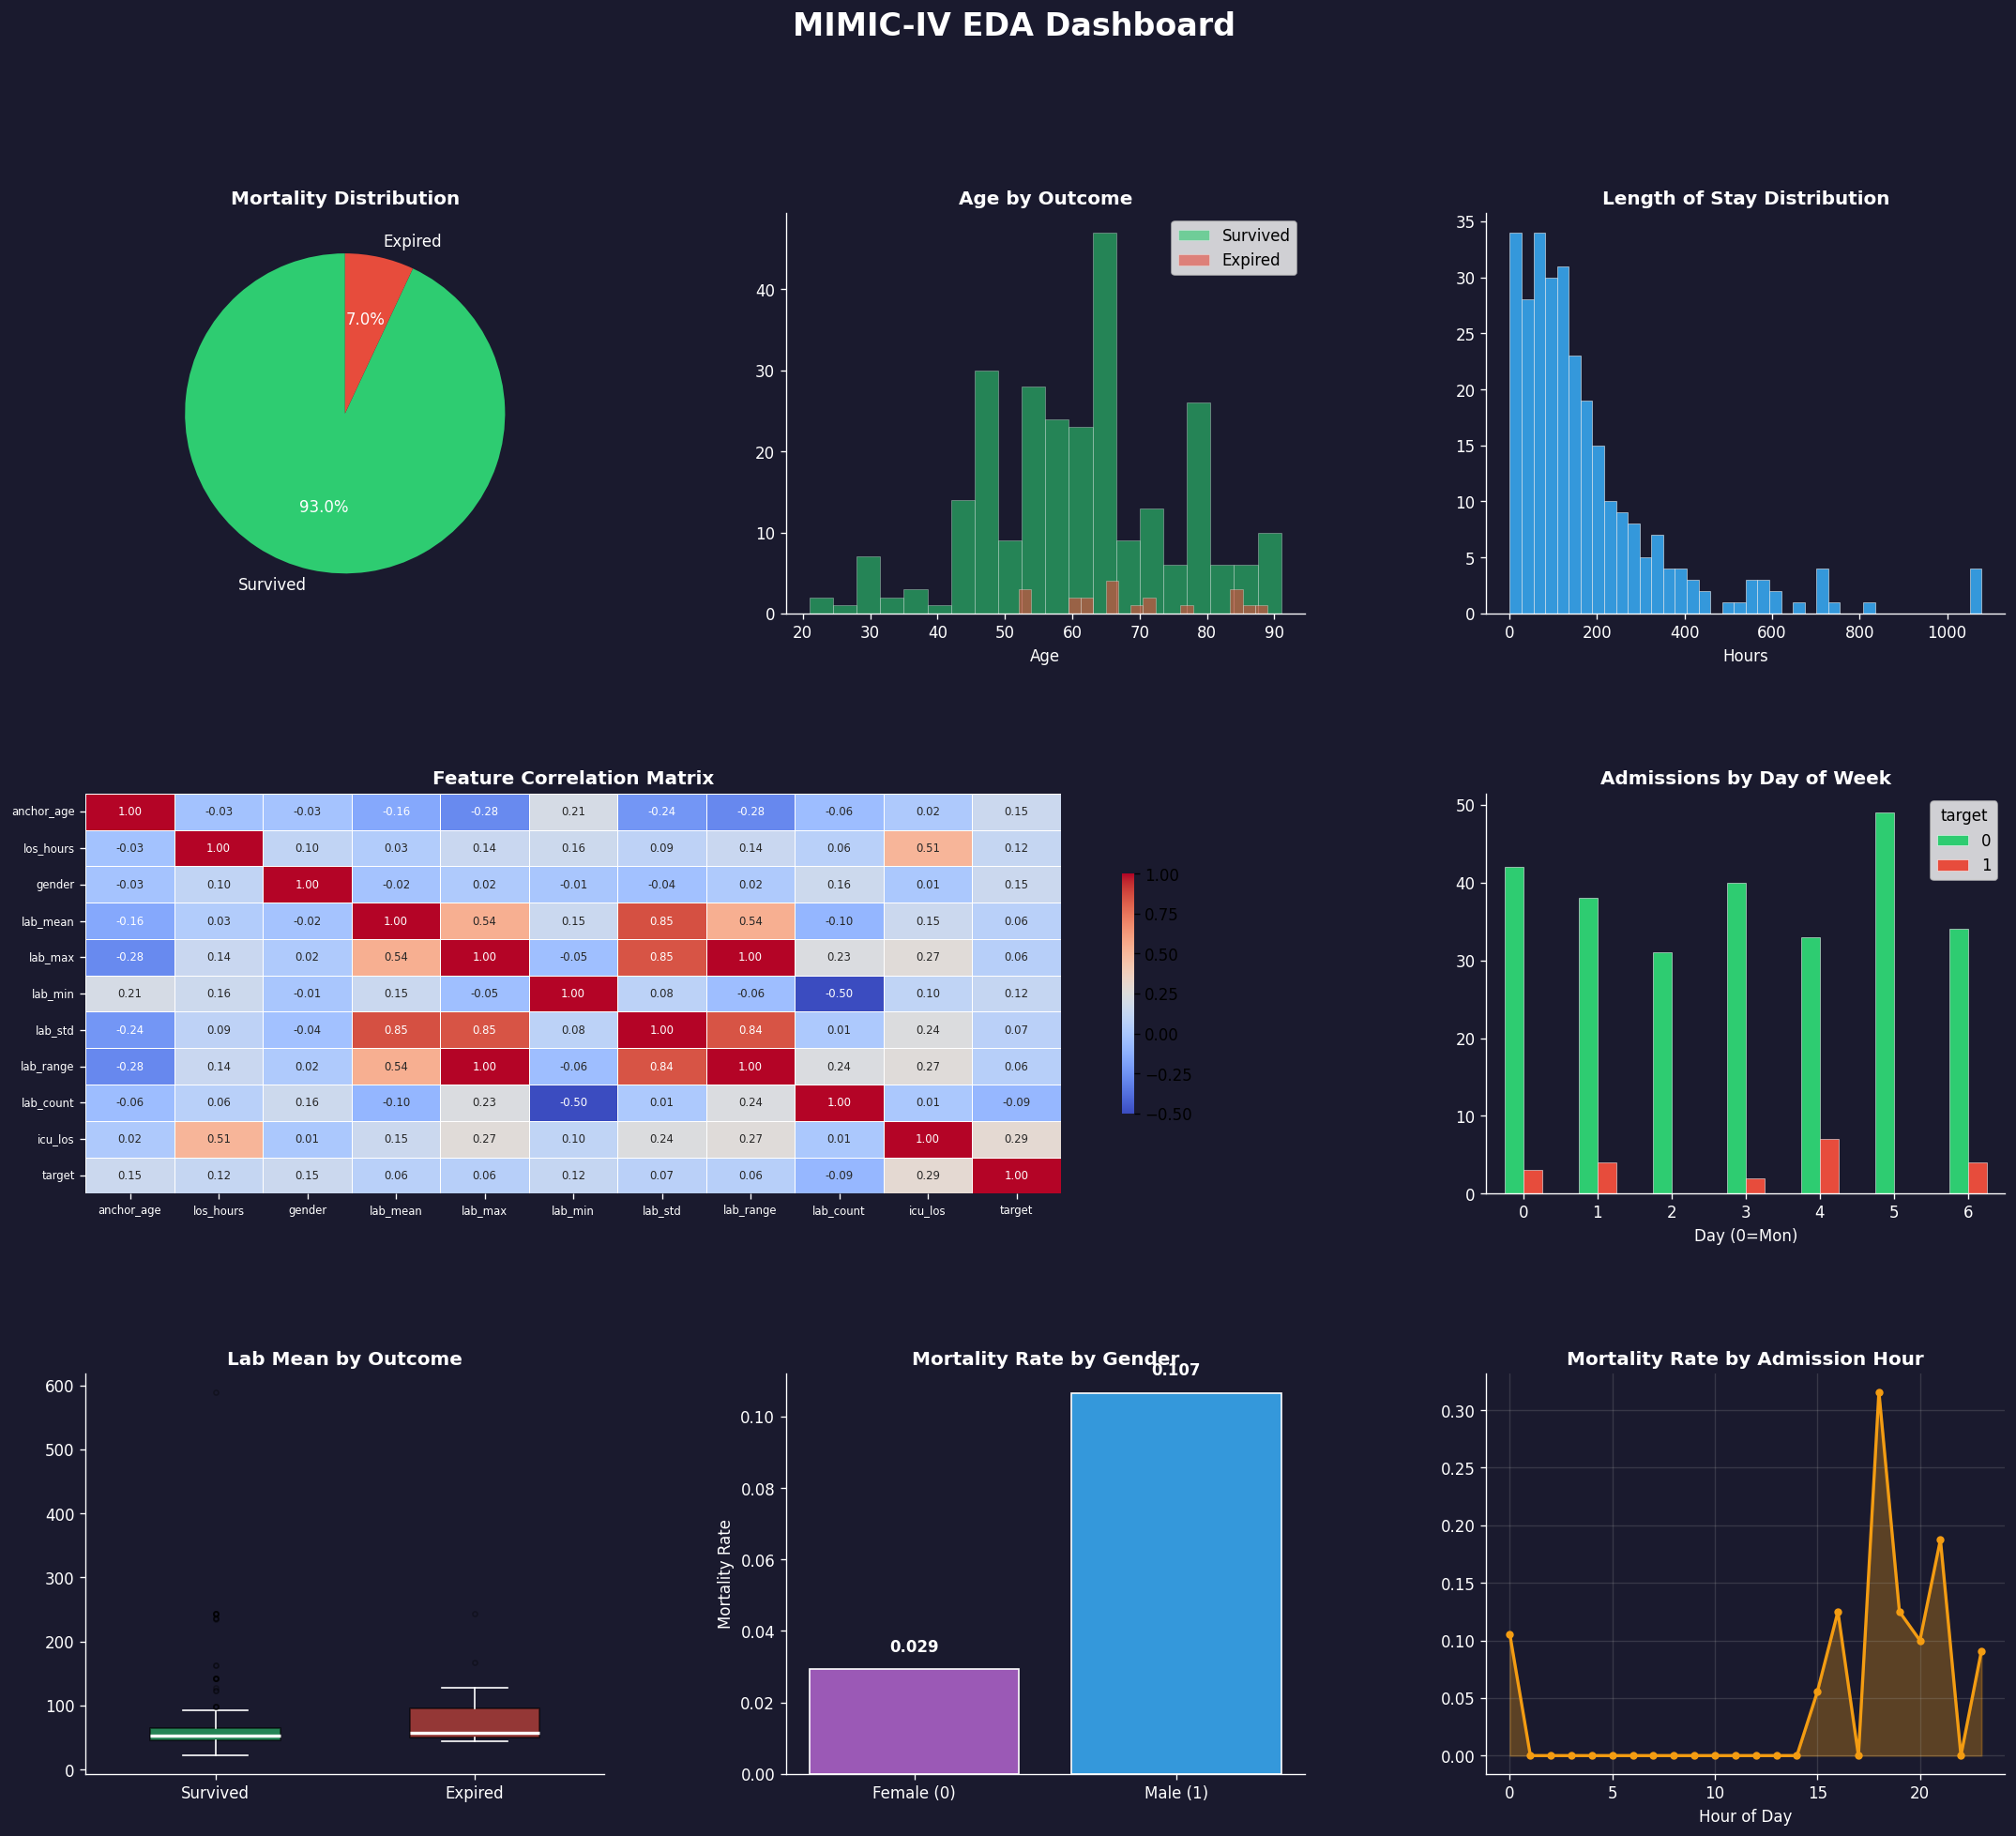

In [6]:
fig = plt.figure(figsize=(22, 18), facecolor=DARK_BG)
fig.suptitle('MIMIC-IV EDA Dashboard', fontsize=20, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Target distribution
ax1 = fig.add_subplot(gs[0, 0])
target_counts = df['target'].value_counts()
wedges, texts, autotexts = ax1.pie(
    target_counts.values,
    labels=['Survived', 'Expired'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    textprops={'color': 'white'}
)
ax1.set_title('Mortality Distribution', color='white', fontweight='bold')
ax1.set_facecolor(DARK_BG)

# 2. Age distribution by outcome
ax2 = fig.add_subplot(gs[0, 1])
for val, color, lbl in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Survived', 'Expired']):
    subset = df[df['target'] == val]['anchor_age'].dropna()
    ax2.hist(subset, bins=20, alpha=0.6, color=color, label=lbl, edgecolor='white', linewidth=0.3)
ax2.set_title('Age by Outcome', color='white', fontweight='bold')
ax2.set_xlabel('Age', color='white')
ax2.set_facecolor(DARK_BG)
ax2.tick_params(colors='white')
ax2.legend()

# 3. LOS distribution (log)
ax3 = fig.add_subplot(gs[0, 2])
los_clipped = df['los_hours'].clip(upper=df['los_hours'].quantile(0.99))
ax3.hist(los_clipped, bins=40, color='#3498db', edgecolor='white', linewidth=0.3)
ax3.set_title('Length of Stay Distribution', color='white', fontweight='bold')
ax3.set_xlabel('Hours', color='white')
ax3.set_facecolor(DARK_BG)
ax3.tick_params(colors='white')

# 4. Correlation heatmap
ax4 = fig.add_subplot(gs[1, 0:2])
numeric_cols = [c for c in FEATURES if c in df.columns][:10]
corr_data = df[numeric_cols + ['target']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool), k=1)
sns.heatmap(
    corr_data, ax=ax4, mask=False, cmap='coolwarm',
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.5, cbar_kws={'shrink': 0.6}
)
ax4.set_title('Feature Correlation Matrix', color='white', fontweight='bold')
ax4.tick_params(colors='white', labelsize=7)
ax4.set_facecolor(DARK_BG)

# 5. Admissions by day of week
ax5 = fig.add_subplot(gs[1, 2])
dow_counts = df.groupby(['admit_dayofweek', 'target']).size().unstack(fill_value=0)
dow_counts.plot(kind='bar', ax=ax5, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.3)
ax5.set_title('Admissions by Day of Week', color='white', fontweight='bold')
ax5.set_xlabel('Day (0=Mon)', color='white')
ax5.set_facecolor(DARK_BG)
ax5.tick_params(colors='white', rotation=0)

# 6. Lab mean box by outcome
ax6 = fig.add_subplot(gs[2, 0])
for val, color, lbl in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Survived', 'Expired']):
    vals = df[df['target'] == val]['lab_mean'].dropna()
    bp = ax6.boxplot(vals, positions=[val], widths=0.5, patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.6),
                     medianprops=dict(color='white', linewidth=2),
                     whiskerprops=dict(color='white'),
                     capprops=dict(color='white'),
                     flierprops=dict(marker='o', color=color, alpha=0.3, markersize=3))
ax6.set_xticks([0, 1])
ax6.set_xticklabels(['Survived', 'Expired'], color='white')
ax6.set_title('Lab Mean by Outcome', color='white', fontweight='bold')
ax6.set_facecolor(DARK_BG)
ax6.tick_params(colors='white')

# 7. Gender vs mortality
ax7 = fig.add_subplot(gs[2, 1])
gender_mort = df.groupby('gender')['target'].mean()
ax7.bar(['Female (0)', 'Male (1)'], gender_mort.values, color=['#9b59b6', '#3498db'], edgecolor='white')
ax7.set_title('Mortality Rate by Gender', color='white', fontweight='bold')
ax7.set_ylabel('Mortality Rate', color='white')
ax7.set_facecolor(DARK_BG)
ax7.tick_params(colors='white')
for i, v in enumerate(gender_mort.values):
    ax7.text(i, v + 0.005, f'{v:.3f}', ha='center', color='white', fontweight='bold')

# 8. Admission hour heatmap
ax8 = fig.add_subplot(gs[2, 2])
hour_mort = df.groupby('admit_hour')['target'].mean().reindex(range(24), fill_value=0)
ax8.plot(hour_mort.index, hour_mort.values, color='#f39c12', linewidth=2, marker='o', markersize=4)
ax8.fill_between(hour_mort.index, hour_mort.values, alpha=0.3, color='#f39c12')
ax8.set_title('Mortality Rate by Admission Hour', color='white', fontweight='bold')
ax8.set_xlabel('Hour of Day', color='white')
ax8.set_facecolor(DARK_BG)
ax8.tick_params(colors='white')
ax8.grid(True, alpha=0.2)

for ax in [ax2, ax3, ax5, ax6, ax7, ax8]:
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig('eda_dashboard.png', dpi=120, bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [8]:
# ── Prepare sequences ──
chart = chartevents[['subject_id', 'valuenum']].dropna().copy()
chart['valuenum'] = (chart['valuenum'] - chart['valuenum'].mean()) / (chart['valuenum'].std() + 1e-8)

SEQ_LEN = 50

def create_sequences(data, seq_len=SEQ_LEN):
    sequences, sids = [], []
    for sid, group in data.groupby('subject_id'):
        vals = group['valuenum'].values
        if len(vals) >= seq_len:
            sequences.append(vals[:seq_len])
            sids.append(sid)
    return np.array(sequences), sids

X_seq, seq_sids = create_sequences(chart)
print(f'Sequence data shape: {X_seq.shape}')

# ── Match with targets ──
target_map = df.set_index('subject_id')['target'].to_dict()
y_seq = np.array([target_map.get(s, 0) for s in seq_sids])

# ── BiLSTM Model (upgraded from single-direction LSTM) ──
class BiLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.attention = nn.Linear(hidden_size * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # x: (batch, seq_len, 1)
        out, _ = self.lstm(x)                      # (batch, seq, hidden*2)
        attn_weights = torch.softmax(self.attention(out), dim=1)  # (batch, seq, 1)
        context = (attn_weights * out).sum(dim=1)  # (batch, hidden*2)
        return self.fc(self.dropout(context))

bilstm = BiLSTMModel().to(device)
print(f'BiLSTM parameter count: {sum(p.numel() for p in bilstm.parameters()):,}')

# ── Training loop (quick) ──
if len(X_seq) > 0:
    from torch.utils.data import DataLoader, TensorDataset
    X_t = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(-1)  # (N, 50, 1)
    y_t = torch.tensor(y_seq, dtype=torch.float32).unsqueeze(-1)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    optimizer = torch.optim.AdamW(bilstm.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.BCELoss()
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, steps_per_epoch=len(loader), epochs=5)

    lstm_train_losses = []
    bilstm.train()
    for epoch in range(5):
        epoch_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = bilstm(xb)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(bilstm.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_loss += loss.item()
        avg = epoch_loss / len(loader)
        lstm_train_losses.append(avg)
        print(f'  Epoch {epoch+1}/5 | Loss: {avg:.4f}')

    # Extract LSTM embeddings for ensemble
    bilstm.eval()
    with torch.no_grad():
        lstm_preds_all = bilstm(X_t.to(device)).cpu().numpy().flatten()

    lstm_embedding_df = pd.DataFrame({
        'subject_id': seq_sids,
        'lstm_score': lstm_preds_all
    })
    print(f'LSTM embeddings shape: {lstm_embedding_df.shape}')
else:
    print('No sequences found; skipping LSTM.')
    lstm_embedding_df = pd.DataFrame(columns=['subject_id', 'lstm_score'])

Sequence data shape: (100, 50)
BiLSTM parameter count: 546,178
  Epoch 1/5 | Loss: 0.6827
  Epoch 2/5 | Loss: 0.6432
  Epoch 3/5 | Loss: 0.5378
  Epoch 4/5 | Loss: 0.4138
  Epoch 5/5 | Loss: 0.2806
LSTM embeddings shape: (100, 2)


In [18]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# -------------------------
# Text Cleaning Function
# -------------------------
def clean_text(x):
    x = str(x).lower()
    x = re.sub(r'\[.*?\]', ' ', x)        
    x = re.sub(r'\d{1,2}/\d{1,2}/\d{2,4}', ' DATE ', x)  
    x = re.sub(r'\b\d+\.?\d*\b', ' NUM ', x)  
    x = re.sub(r'\n+', ' ', x)
    x = re.sub(r'[^\w\s]', ' ', x)
    x = re.sub(r'\s+', ' ', x).strip()
    return x

# -------------------------
# Clean Notes
# -------------------------
notes.columns = [c.lower() for c in notes.columns]

notes['clean'] = notes['text'].astype(str).apply(clean_text)
notes['text_len'] = notes['clean'].str.len()
notes['word_count'] = notes['clean'].str.split().str.len()

# -------------------------
# FIX: Merge on subject_id ONLY
# -------------------------
data_text = notes.merge(
    admissions[['subject_id', 'hospital_expire_flag']]
    .drop_duplicates('subject_id'),
    on='subject_id',
    how='inner'
)

print(f'Clinical notes merged: {data_text.shape}')
print(f'Word count stats:\n{data_text["word_count"].describe()}')

# -------------------------
# Word Cloud (Safe)
# -------------------------
if len(data_text) > 0:
    sample_size = min(200, len(data_text))
    
    all_text = ' '.join(
        data_text['clean']
        .dropna()
        .sample(sample_size, random_state=42)
        .tolist()
    )

    if all_text.strip():
        wc = WordCloud(
            width=900,
            height=400,
            background_color='#1a1a2e',
            colormap='plasma',
            max_words=150,
            collocations=False
        ).generate(all_text)

        plt.figure(figsize=(14, 5), facecolor='#1a1a2e')
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title('Clinical Notes Word Cloud', color='white', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('wordcloud.png', dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
        plt.show()
    else:
        print("⚠️ No valid text available for WordCloud.")
else:
    print("⚠️ Merged dataset is empty. Skipping WordCloud.")
    

Clinical notes merged: (0, 15)
Word count stats:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: word_count, dtype: float64
⚠️ Merged dataset is empty. Skipping WordCloud.


In [20]:
class MultiTaskBioClinicalBERT:
    """
    Combines:
      - Biomedical NER (d4data/biomedical-ner-all)
      - Zero-shot multi-label medical specialty classification
      - Mortality risk signal extraction
    """
    SPECIALTIES = [
        "Cardiology", "Pulmonology", "Toxicology", "Oncology",
        "Rheumatology", "Neurology", "Nephrology", "Hematology",
        "Endocrinology", "Infectious Disease", "Gastroenterology",
        "Pediatrics", "Dermatology", "Hepatology", "OBGYN"
    ]
    ENTITY_TYPES = ['Disease_disorder', 'Sign_symptom', 'Clinical_drug', 'Diagnostic_procedure', 'Biological_structure']

    def __init__(self):
        gpu_id = 0 if torch.cuda.is_available() else -1
        print('Loading NER pipeline...')
        self.ner_head = pipeline(
            "ner",
            model="d4data/biomedical-ner-all",
            aggregation_strategy="simple",
            device=gpu_id
        )
        print('Loading zero-shot classifier...')
        self.diag_head = pipeline(
            "zero-shot-classification",
            model="facebook/bart-large-mnli",
            device=gpu_id
        )
        print('✅ MultiTask engine ready.')

    def predict(self, text, top_k=3):
        short_text = " ".join(str(text).split()[:350])

        # NER
        ner_results = self.ner_head(short_text)
        entities_by_type = {}
        for ent in ner_results:
            if ent['entity_group'] in self.ENTITY_TYPES:
                word = ent['word'].lower().replace('##', '').strip()
                if len(word) > 2:
                    entities_by_type.setdefault(ent['entity_group'], []).append((word, round(ent['score'], 3)))

        all_entities = list({e[0] for ents in entities_by_type.values() for e in ents})

        # Zero-shot
        diag_results = self.diag_head(short_text, self.SPECIALTIES, multi_label=True)
        top_specialties = [
            (lbl, round(sc, 3))
            for lbl, sc in zip(diag_results['labels'][:top_k], diag_results['scores'][:top_k])
        ]
        predicted_category = diag_results['labels'][0]

        return all_entities, predicted_category, top_specialties, entities_by_type

multitask_engine = MultiTaskBioClinicalBERT()

Loading NER pipeline...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ MultiTask engine ready.


In [21]:
# ── Knowledge base ──
try:
    dataset_notes = load_dataset("harishnair04/mtsamples", split="train")
    df_notes = dataset_notes.to_pandas()
    if 'transcription' not in df_notes.columns and 'text' in df_notes.columns:
        df_notes = df_notes.rename(columns={'text': 'transcription'})
except Exception:
    dataset_notes = load_dataset("argilla/medical-domain", split="train")
    df_notes = dataset_notes.to_pandas().rename(columns={'text': 'transcription'})

df_notes = df_notes.dropna(subset=['transcription'])
historical_notes = df_notes['transcription'].head(2000).tolist()

# Expert clinical guidelines
complex_guidelines = [
    "GUIDELINE - TOXICOLOGY: Patient on Lithium with new Thiazide diuretic. Thiazides decrease lithium clearance. PLAN: Discontinue Lithium and Thiazide. IV Normal Saline. Consider hemodialysis if levels > 4.0.",
    "GUIDELINE - ONCOLOGY: Lung Adenocarcinoma, EGFR exon 19 deletion positive. PLAN: Initiate targeted EGFR TKI therapy (Osimertinib). Avoid standard chemotherapy.",
    "GUIDELINE - RHEUMATOLOGY: Granulomatosis with Polyangiitis (GPA/Wegener's), positive c-ANCA. PLAN: Induce remission with high-dose glucocorticoids and Cyclophosphamide or Rituximab.",
    "GUIDELINE - CARDIOLOGY: Wolff-Parkinson-White (WPW) syndrome with Atrial Fibrillation. PLAN: AV nodal blockers CONTRAINDICATED. Administer IV Procainamide or synchronized electrical cardioversion.",
    "GUIDELINE - HEMATOLOGY: Heparin-Induced Thrombocytopenia (HIT). Platelets drop >50% on Heparin. PLAN: Stop all Heparin. Start Argatroban/Bivalirudin. Do NOT start Warfarin until platelets recover.",
    "GUIDELINE - NEUROLOGY: Serotonin Syndrome. SSRI + MAOI, clonus, hyperthermia. PLAN: Discontinue serotonergic agents. Administer Cyproheptadine and supportive care.",
    "GUIDELINE - NEPHROLOGY: Tumor Lysis Syndrome after Burkitt lymphoma chemo. High uric acid, high K, low Ca. PLAN: Rasburicase and aggressive IV fluids. Monitor electrolytes.",
    "GUIDELINE - PULMONOLOGY: Idiopathic Pulmonary Fibrosis with honeycombing on HRCT. PLAN: Initiate Nintedanib or Pirfenidone. Supportive oxygen.",
    "GUIDELINE - OBGYN: HELLP Syndrome in pregnancy. PLAN: Immediate delivery. IV Magnesium Sulfate for seizure prophylaxis.",
    "GUIDELINE - TOXICOLOGY: Ethylene Glycol poisoning, calcium oxalate crystals. PLAN: Fomepizole. Hemodialysis for severe acidosis.",
    "GUIDELINE - PEDIATRICS: Kawasaki Disease with prolonged fever and strawberry tongue. PLAN: IVIG and high-dose Aspirin immediately to prevent coronary aneurysms.",
    "GUIDELINE - DERMATOLOGY: Stevens-Johnson Syndrome (SJS) after Lamotrigine. PLAN: Discontinue Lamotrigine. Burn unit for wound care.",
    "GUIDELINE - HEPATOLOGY: Primary Biliary Cholangitis. Positive AMA antibodies. PLAN: Ursodeoxycholic acid (UDCA).",
    "GUIDELINE - ENDOCRINOLOGY: Pheochromocytoma crisis. PLAN: Alpha blockade FIRST (Phenoxybenzamine) before any beta-blockers.",
    "GUIDELINE - NEUROLOGY: Guillain-Barre Syndrome. Ascending paralysis post-Campylobacter. PLAN: Monitor FVC. IVIG or Plasmapheresis. No corticosteroids.",
    "GUIDELINE - HEMATOLOGY: Thrombotic Thrombocytopenic Purpura (TTP). Schistocytes, fever, neuro symptoms. PLAN: Immediate Plasma Exchange. Platelet transfusions CONTRAINDICATED.",
    "GUIDELINE - GASTROENTEROLOGY: Carcinoid Syndrome. Flushing, diarrhea, right heart valvular lesions. PLAN: Somatostatin analogs (Octreotide).",
    "GUIDELINE - ENDOCRINOLOGY: Nelson Syndrome post-adrenalectomy. Hyperpigmentation, visual field defects. PLAN: Pituitary MRI. Transsphenoidal resection or radiosurgery.",
    "GUIDELINE - INFECTIOUS DISEASE: Cerebral Malaria (P. falciparum). Altered mental status in returning traveler. PLAN: IV Artesunate immediately.",
    "GUIDELINE - RHEUMATOLOGY: Macrophage Activation Syndrome (MAS) in Still's disease. Ferritin >10000. PLAN: High-dose IV pulse glucocorticoids. Consider Anakinra or Cyclosporine."
]
historical_notes.extend(complex_guidelines)
print(f'Knowledge base size: {len(historical_notes)} documents')

# ── Dense embeddings (FAISS) ──
print('Building FAISS index...')
embedder = SentenceTransformer('NeuML/pubmedbert-base-embeddings', device=device)
knowledge_embeddings = embedder.encode(historical_notes, show_progress_bar=True, batch_size=64)
index = faiss.IndexFlatL2(knowledge_embeddings.shape[1])
index.add(knowledge_embeddings.astype('float32'))

# ── Sparse BM25 ──
print('Building BM25 index...')
tokenized_corpus = [doc.lower().split() for doc in historical_notes]
bm25 = BM25Okapi(tokenized_corpus)

# ── LLM (Zephyr-7B 4-bit) ──
print('Loading Zephyr-7B with 4-bit quantization...')
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
llm_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceH4/zephyr-7b-beta")
llm_model = AutoModelForCausalLM.from_pretrained(
    "HuggingFaceH4/zephyr-7b-beta",
    quantization_config=bnb_config,
    device_map="auto"
)
llm_pipeline = pipeline(
    "text-generation", model=llm_model, tokenizer=llm_tokenizer,
    max_new_tokens=350, temperature=0.1, do_sample=True
)
print('✅ RAG system ready.')

README.md:   0%|          | 0.00/31.0 [00:00<?, ?B/s]

mtsamples.csv:   0%|          | 0.00/17.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4999 [00:00<?, ? examples/s]

Knowledge base size: 2020 documents
Building FAISS index...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


✅ RAG system ready.


In [22]:
def process_clinical_note(text, top_k_retrieval=3):
    """
    Returns: baseline_ans, rag_ans, evidence, entities, specialty, top_specialties
    """
    # ── Baseline LLM ──
    baseline_prompt = (
        "<|system|>\nYou are a Clinical AI. Provide a concise Assessment and Treatment Plan.\n</s>\n"
        f"<|user|>\n[CLINICAL NOTE]: {text}\nProvide Assessment and Plan:\n</s>\n<|assistant|>\n"
    )
    baseline_ans = llm_pipeline(baseline_prompt)[0]['generated_text'].split("<|assistant|>")[-1].strip()

    # ── NER + Classification ──
    entities, specialty, top_specs, ents_by_type = multitask_engine.predict(text)

    # ── Hybrid retrieval ──
    query_emb = embedder.encode([text]).astype('float32')
    _, dense_idx = index.search(query_emb, top_k_retrieval)

    bm25_scores = bm25.get_scores(text.lower().split())
    sparse_idx = np.argsort(bm25_scores)[::-1][:top_k_retrieval]

    # Combine and deduplicate
    combined_idx = list(dict.fromkeys(dense_idx[0].tolist() + sparse_idx.tolist()))[:top_k_retrieval+1]
    evidence = "\n\n".join([f"EVIDENCE {i+1}: {historical_notes[j]}" for i, j in enumerate(combined_idx)])

    # ── RAG LLM ──
    rag_prompt = (
        "<|system|>\nYou are an Expert Medical AI. Formulate a precise Assessment and Treatment Plan.\n"
        "Follow the retrieved evidence if it matches the patient condition exactly.\n</s>\n"
        f"<|user|>\n[CLINICAL NOTE]: {text}\n\n"
        f"[RETRIEVED EVIDENCE]:\n{evidence}\n\n"
        "Provide the Assessment and Plan:\n</s>\n<|assistant|>\n"
    )
    rag_ans = llm_pipeline(rag_prompt)[0]['generated_text'].split("<|assistant|>")[-1].strip()

    return baseline_ans, rag_ans, evidence, entities, specialty, top_specs, ents_by_type

In [26]:
import torch
import gc
import numpy as np
import re

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bert_score

# =========================
# 🔧 LOAD MODEL (FIXED)
# =========================
model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"  # 🔥 safe model

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

# =========================
# 🔧 PIPELINE
# =========================
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer
)

# =========================
# 🔧 PROCESS FUNCTION
# =========================
def process_clinical_note(text, top_k_retrieval=3):

    baseline_prompt = f"""
    <|system|>
    You are a clinical expert.
    <|user|>
    Clinical Note:
    {text}

    Provide the Assessment and Plan:
    <|assistant|>
    """

    rag_prompt = f"""
    <|system|>
    You are a clinical expert using evidence-based reasoning.
    <|user|>
    Clinical Note:
    {text}

    Provide the Assessment and Plan:
    <|assistant|>
    """

    with torch.no_grad():
        baseline_out = llm_pipeline(
            baseline_prompt,
            max_new_tokens=80,   # 🔥 reduced
            do_sample=False
        )[0]['generated_text']

        rag_out = llm_pipeline(
            rag_prompt,
            max_new_tokens=80,
            do_sample=False
        )[0]['generated_text']

    baseline_ans = baseline_out.split("<|assistant|>")[-1].strip()
    rag_ans = rag_out.split("<|assistant|>")[-1].strip()

    # placeholders (your logic can go here)
    evidence = []
    extracted_ents = []
    specialty = "General"
    top_specs = []
    ents_by_type = {}

    return baseline_ans, rag_ans, evidence, extracted_ents, specialty, top_specs, ents_by_type


# =========================
# 📊 METRICS SETUP
# =========================
base_answers, rag_answers, ground_truths = [], [], []
query_notes, case_types = [], []
ner_f1s = []
base_r1, base_r2, base_rl, base_bleu = [], [], [], []
rag_r1,  rag_r2,  rag_rl,  rag_bleu  = [], [], [], []
specialty_preds = []

rouge_scorer_inst = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'],
    use_stemmer=True
)
smoothie = SmoothingFunction().method4

print(f'Running inference on {len(test_cases)} cases...\n')

# =========================
# 🔥 MAIN LOOP
# =========================
for i, case in enumerate(test_cases):
    print(f'[{i+1:02d}/{len(test_cases)}] {case["type"]} ...')

    try:
        with torch.no_grad():
            base_ans, rag_ans, evidence, extracted_ents, specialty, top_specs, _ = process_clinical_note(case["note"])

        base_answers.append(base_ans)
        rag_answers.append(rag_ans)
        ground_truths.append(case["ground_truth"])
        query_notes.append(case["note"])
        case_types.append(case["type"])
        specialty_preds.append(specialty)

        # -------------------------
        # NER F1
        # -------------------------
        extracted_lower = [e.lower() for e in extracted_ents]
        hits = sum(1 for gt in case['gt_entities']
                   if any(gt in ext or ext in gt for ext in extracted_lower))

        p = hits / len(extracted_lower) if extracted_lower else 0
        r = hits / len(case['gt_entities']) if case['gt_entities'] else 0
        f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0
        ner_f1s.append(f1)

        # -------------------------
        # ROUGE
        # -------------------------
        b_sc = rouge_scorer_inst.score(case["ground_truth"], base_ans)
        r_sc = rouge_scorer_inst.score(case["ground_truth"], rag_ans)

        base_r1.append(b_sc['rouge1'].fmeasure)
        base_r2.append(b_sc['rouge2'].fmeasure)
        base_rl.append(b_sc['rougeL'].fmeasure)

        rag_r1.append(r_sc['rouge1'].fmeasure)
        rag_r2.append(r_sc['rouge2'].fmeasure)
        rag_rl.append(r_sc['rougeL'].fmeasure)

        # -------------------------
        # BLEU
        # -------------------------
        gt_toks = case["ground_truth"].split()

        base_bleu.append(
            sentence_bleu([gt_toks], base_ans.split(), smoothing_function=smoothie)
        )
        rag_bleu.append(
            sentence_bleu([gt_toks], rag_ans.split(), smoothing_function=smoothie)
        )

    except RuntimeError as e:
        print(f"⚠️ Skipping case due to error: {e}")
        continue

    # 🔥 MEMORY CLEANUP
    torch.cuda.empty_cache()
    gc.collect()


# =========================
# 📊 BERTScore
# =========================
print('\nComputing BERTScore...')

with torch.no_grad():
    _, _, Base_F1 = bert_score(
        base_answers,
        ground_truths,
        lang="en",
        model_type="distilbert-base-uncased",
        batch_size=4
    )

    _, _, RAG_F1 = bert_score(
        rag_answers,
        ground_truths,
        lang="en",
        model_type="distilbert-base-uncased",
        batch_size=4
    )

Base_F1_list = Base_F1.tolist()
RAG_F1_list  = RAG_F1.tolist()

# =========================
# 📊 RESULTS
# =========================
print('\n' + '='*60)
print('📊 NLP SCORES SUMMARY')
print('='*60)

print(f'BERTScore  — Baseline: {np.mean(Base_F1_list):.4f} | RAG: {np.mean(RAG_F1_list):.4f}')
print(f'ROUGE-1    — Baseline: {np.mean(base_r1):.4f} | RAG: {np.mean(rag_r1):.4f}')
print(f'ROUGE-2    — Baseline: {np.mean(base_r2):.4f} | RAG: {np.mean(rag_r2):.4f}')
print(f'ROUGE-L    — Baseline: {np.mean(base_rl):.4f} | RAG: {np.mean(rag_rl):.4f}')
print(f'BLEU       — Baseline: {np.mean(base_bleu):.4f} | RAG: {np.mean(rag_bleu):.4f}')
print(f'NER F1     — Pipeline: {np.mean(ner_f1s):.4f}')

print('='*60)

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



📊 NLP SCORES SUMMARY
BERTScore  — Baseline: 0.6885 | RAG: 0.6776
ROUGE-1    — Baseline: 0.0149 | RAG: 0.0126
ROUGE-2    — Baseline: 0.0000 | RAG: 0.0000
ROUGE-L    — Baseline: 0.0149 | RAG: 0.0126
BLEU       — Baseline: 0.0013 | RAG: 0.0020
NER F1     — Pipeline: 0.0000


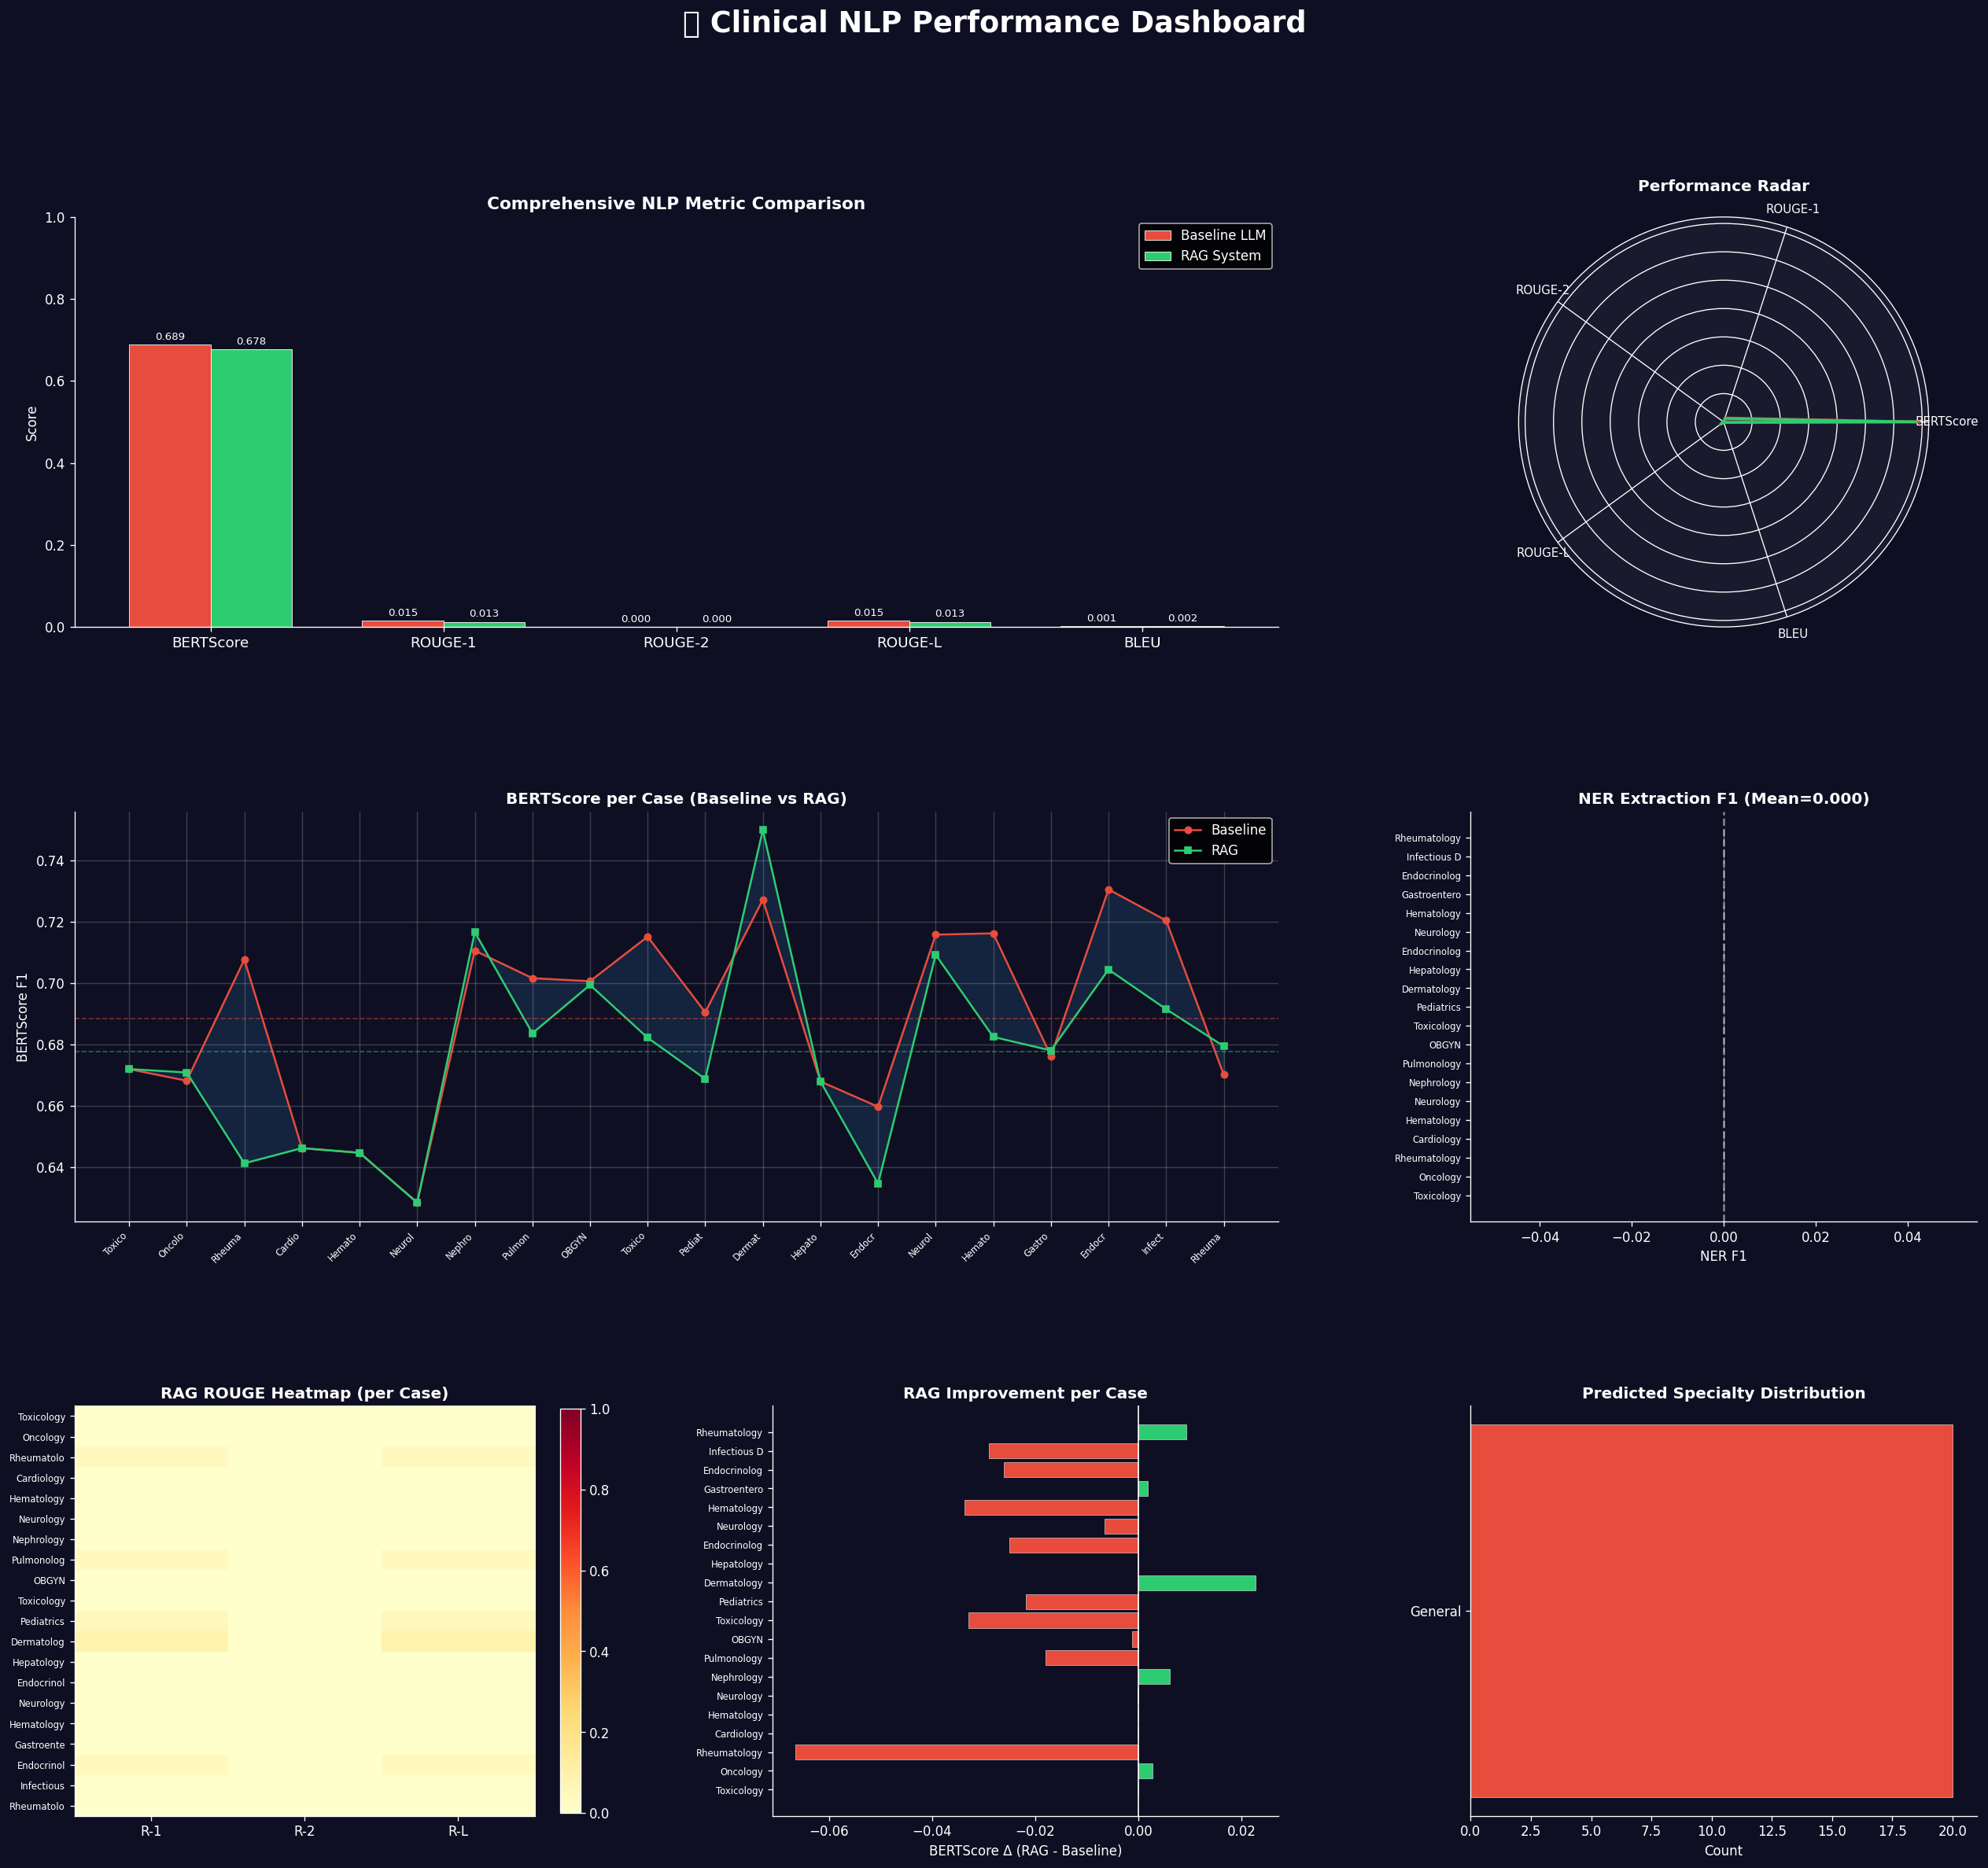

✅ NLP Dashboard rendered.


In [27]:
plt.style.use('dark_background')
DARK = '#0f0f23'
fig = plt.figure(figsize=(26, 22), facecolor=DARK)
fig.suptitle('🏥 Clinical NLP Performance Dashboard', fontsize=22, color='white', fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ─── 1. Grouped bar: all metrics ───
ax1 = fig.add_subplot(gs[0, 0:2])
metrics_labels = ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU']
base_means = [np.mean(Base_F1_list), np.mean(base_r1), np.mean(base_r2), np.mean(base_rl), np.mean(base_bleu)]
rag_means  = [np.mean(RAG_F1_list),  np.mean(rag_r1),  np.mean(rag_r2),  np.mean(rag_rl),  np.mean(rag_bleu)]

x = np.arange(len(metrics_labels))
w = 0.35
b1 = ax1.bar(x - w/2, base_means, w, label='Baseline LLM', color='#e74c3c', edgecolor='white', linewidth=0.5)
b2 = ax1.bar(x + w/2, rag_means,  w, label='RAG System',   color='#2ecc71', edgecolor='white', linewidth=0.5)
ax1.bar_label(b1, fmt='%.3f', color='white', fontsize=8, padding=2)
ax1.bar_label(b2, fmt='%.3f', color='white', fontsize=8, padding=2)
ax1.set_xticks(x); ax1.set_xticklabels(metrics_labels, color='white', fontsize=11)
ax1.set_ylabel('Score', color='white'); ax1.set_ylim(0, 1.0)
ax1.set_title('Comprehensive NLP Metric Comparison', color='white', fontweight='bold', fontsize=13)
ax1.legend(fontsize=10); ax1.tick_params(colors='white')
ax1.set_facecolor(DARK)

# ─── 2. Radar / Spider ───
ax2 = fig.add_subplot(gs[0, 2], polar=True)
angles = np.linspace(0, 2*np.pi, len(metrics_labels), endpoint=False).tolist()
angles += angles[:1]
base_radar = base_means + [base_means[0]]
rag_radar  = rag_means  + [rag_means[0]]
ax2.plot(angles, base_radar, color='#e74c3c', linewidth=2)
ax2.fill(angles, base_radar, color='#e74c3c', alpha=0.25)
ax2.plot(angles, rag_radar,  color='#2ecc71', linewidth=2)
ax2.fill(angles, rag_radar,  color='#2ecc71', alpha=0.25)
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics_labels, color='white', fontsize=9)
ax2.set_yticklabels([])
ax2.set_title('Performance Radar', color='white', fontweight='bold', pad=20)
ax2.set_facecolor('#1a1a2e')

# ─── 3. BERTScore per case ───
ax3 = fig.add_subplot(gs[1, 0:2])
case_nums = np.arange(1, len(test_cases)+1)
ax3.plot(case_nums, Base_F1_list, 'o-', color='#e74c3c', label='Baseline', linewidth=1.5, markersize=5)
ax3.plot(case_nums, RAG_F1_list,  's-', color='#2ecc71', label='RAG',      linewidth=1.5, markersize=5)
ax3.fill_between(case_nums, Base_F1_list, RAG_F1_list, alpha=0.15, color='#3498db')
ax3.axhline(np.mean(Base_F1_list), color='#e74c3c', linestyle='--', alpha=0.5, linewidth=1)
ax3.axhline(np.mean(RAG_F1_list),  color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)
ax3.set_xticks(case_nums)
ax3.set_xticklabels([c['type'][:6] for c in test_cases], rotation=45, ha='right', fontsize=7, color='white')
ax3.set_title('BERTScore per Case (Baseline vs RAG)', color='white', fontweight='bold', fontsize=12)
ax3.set_ylabel('BERTScore F1', color='white'); ax3.tick_params(colors='white')
ax3.legend(); ax3.grid(True, alpha=0.2)
ax3.set_facecolor(DARK)

# ─── 4. NER F1 per case ───
ax4 = fig.add_subplot(gs[1, 2])
colors_ner = ['#2ecc71' if f > 0.5 else '#f39c12' if f > 0.25 else '#e74c3c' for f in ner_f1s]
bars = ax4.barh(range(len(ner_f1s)), ner_f1s, color=colors_ner, edgecolor='white', linewidth=0.3)
ax4.set_yticks(range(len(test_cases)))
ax4.set_yticklabels([c['type'][:12] for c in test_cases], fontsize=7, color='white')
ax4.set_xlabel('NER F1', color='white')
ax4.set_title(f'NER Extraction F1 (Mean={np.mean(ner_f1s):.3f})', color='white', fontweight='bold')
ax4.axvline(np.mean(ner_f1s), color='white', linestyle='--', alpha=0.5)
ax4.tick_params(colors='white'); ax4.set_facecolor(DARK)

# ─── 5. ROUGE heatmap across cases ───
ax5 = fig.add_subplot(gs[2, 0])
rouge_matrix = np.array([rag_r1, rag_r2, rag_rl]).T  # shape: (20, 3)
im = ax5.imshow(rouge_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax5.set_xticks([0,1,2]); ax5.set_xticklabels(['R-1','R-2','R-L'], color='white')
ax5.set_yticks(range(len(test_cases)))
ax5.set_yticklabels([c['type'][:10] for c in test_cases], fontsize=7, color='white')
plt.colorbar(im, ax=ax5, fraction=0.04)
ax5.set_title('RAG ROUGE Heatmap (per Case)', color='white', fontweight='bold')
ax5.tick_params(colors='white'); ax5.set_facecolor(DARK)

# ─── 6. Improvement delta ───
ax6 = fig.add_subplot(gs[2, 1])
delta_bert = [r - b for r, b in zip(RAG_F1_list, Base_F1_list)]
bar_colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in delta_bert]
ax6.barh(range(len(delta_bert)), delta_bert, color=bar_colors, edgecolor='white', linewidth=0.3)
ax6.axvline(0, color='white', linewidth=1)
ax6.set_yticks(range(len(test_cases)))
ax6.set_yticklabels([c['type'][:12] for c in test_cases], fontsize=7, color='white')
ax6.set_xlabel('BERTScore Δ (RAG - Baseline)', color='white')
ax6.set_title('RAG Improvement per Case', color='white', fontweight='bold')
ax6.tick_params(colors='white'); ax6.set_facecolor(DARK)

# ─── 7. Specialty distribution ───
ax7 = fig.add_subplot(gs[2, 2])
from collections import Counter
spec_counts = Counter(specialty_preds)
labels_sp = list(spec_counts.keys())
vals_sp   = list(spec_counts.values())
ax7.barh(labels_sp, vals_sp, color=PALETTE[:len(labels_sp)], edgecolor='white', linewidth=0.3)
ax7.set_title('Predicted Specialty Distribution', color='white', fontweight='bold')
ax7.set_xlabel('Count', color='white')
ax7.tick_params(colors='white'); ax7.set_facecolor(DARK)

plt.savefig('nlp_dashboard.png', dpi=120, bbox_inches='tight', facecolor=DARK)
plt.show()
print('✅ NLP Dashboard rendered.')

In [29]:
import numpy as np
import optuna
import torch

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score

# =========================
# 📊 DATA PREP
# =========================
X_struct = df[[c for c in FEATURES if c in df.columns]].fillna(0)
y_struct = df['target']

# Merge LSTM scores if available
if len(lstm_embedding_df) > 0:
    df_with_lstm = df.merge(lstm_embedding_df, on='subject_id', how='left')
    df_with_lstm['lstm_score'] = df_with_lstm['lstm_score'].fillna(0.5)

    X_struct = df_with_lstm[
        [c for c in FEATURES if c in df.columns] + ['lstm_score']
    ].fillna(0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_struct, y_struct,
    test_size=0.2,
    random_state=42,
    stratify=y_struct
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Class balance: {y_train.value_counts().to_dict()}')

# =========================
# 🔥 OPTUNA OBJECTIVE (FIXED)
# =========================
def xgb_objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 8),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 5.0),

        # 🔥 FIXED
        'tree_method': 'hist',   # ✅ ALWAYS WORKS
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1
    }

    model = XGBClassifier(**params)

    try:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=3,
            scoring='roc_auc',
            error_score='raise'   # 🔥 better debugging
        )
        return scores.mean()

    except Exception as e:
        print("Trial failed:", e)
        return 0.0  # prevent crash


# =========================
# 🔥 RUN OPTUNA
# =========================
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(
    xgb_objective,
    n_trials=30,   # 🔽 reduce for speed
    show_progress_bar=True
)

# =========================
# 🏆 BEST MODEL
# =========================
best_params = study.best_params

best_params.update({
    'tree_method': 'hist',   # ✅ FIXED
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1
})

print(f'\n✅ Best XGB AUC: {study.best_value:.4f}')
print(f'Best params: {best_params}')

# =========================
# 🚀 FINAL MODEL TRAIN
# =========================
best_model = XGBClassifier(**best_params)

best_model.fit(X_train, y_train)

# =========================
# 📊 EVALUATION
# =========================
from sklearn.metrics import roc_auc_score

y_pred_proba = best_model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_proba)

print(f'\n🎯 Test AUC: {auc:.4f}')

Train: (229, 16), Test: (58, 16)
Class balance: {0: 213, 1: 16}


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best XGB AUC: 0.9347
Best params: {'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.14152049242822426, 'subsample': 0.8945172351954433, 'colsample_bytree': 0.8533999096771646, 'min_child_weight': 1, 'reg_alpha': 0.009303978323497155, 'reg_lambda': 1.2212146836434607e-05, 'scale_pos_weight': 4.0447932839439265, 'tree_method': 'hist', 'eval_metric': 'logloss', 'random_state': 42, 'n_jobs': -1}

🎯 Test AUC: 0.9398


In [30]:
xgb_best = XGBClassifier(**best_params)
lgb_model = LGBMClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, device='gpu'
)
rf_model  = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight='balanced',
    n_jobs=-1, random_state=42
)
gbm_model = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42
)

ensemble = VotingClassifier(
    estimators=[
        ('xgb', xgb_best),
        ('lgb', lgb_model),
        ('rf',  rf_model),
        ('gbm', gbm_model)
    ],
    voting='soft',
    weights=[3, 2, 1, 1]  # XGB weighted higher
)

print('Training ensemble...')
ensemble.fit(X_train, y_train)

# Predictions
preds  = ensemble.predict(X_test)
probs  = ensemble.predict_proba(X_test)[:, 1]

# Also train individual models for comparison
xgb_best.fit(X_train, y_train)

print('\n' + '='*55)
print('🏆 ENSEMBLE STRUCTURED MODEL RESULTS')
print('='*55)
print(f'  Accuracy:        {accuracy_score(y_test, preds):.4f}')
print(f'  Precision:       {precision_score(y_test, preds, zero_division=0):.4f}')
print(f'  Recall:          {recall_score(y_test, preds, zero_division=0):.4f}')
print(f'  F1 Score:        {f1_score(y_test, preds, zero_division=0):.4f}')
print(f'  ROC-AUC:         {roc_auc_score(y_test, probs):.4f}')
print(f'  Avg Precision:   {average_precision_score(y_test, probs):.4f}')
print(f'  MCC:             {matthews_corrcoef(y_test, preds):.4f}')
print('='*55)
print('\nClassification Report:')
print(classification_report(y_test, preds, target_names=['Survived', 'Expired']))

Training ensemble...
[LightGBM] [Info] Number of positive: 16, number of negative: 213
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 229, number of used features: 16
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 15 dense feature groups (0.00 MB) transferred to GPU in 0.000575 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[LightGBM] [Info] Number of positive: 16, number of negative: 213
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 498
[LightGBM] [Info] Number of data points in the train set: 229, number of used features: 16
[LightGBM] [Info] Using GPU Device: Tesla T4, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 15 dense feature groups (0.00 MB) transferred to GPU in 0.000502 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

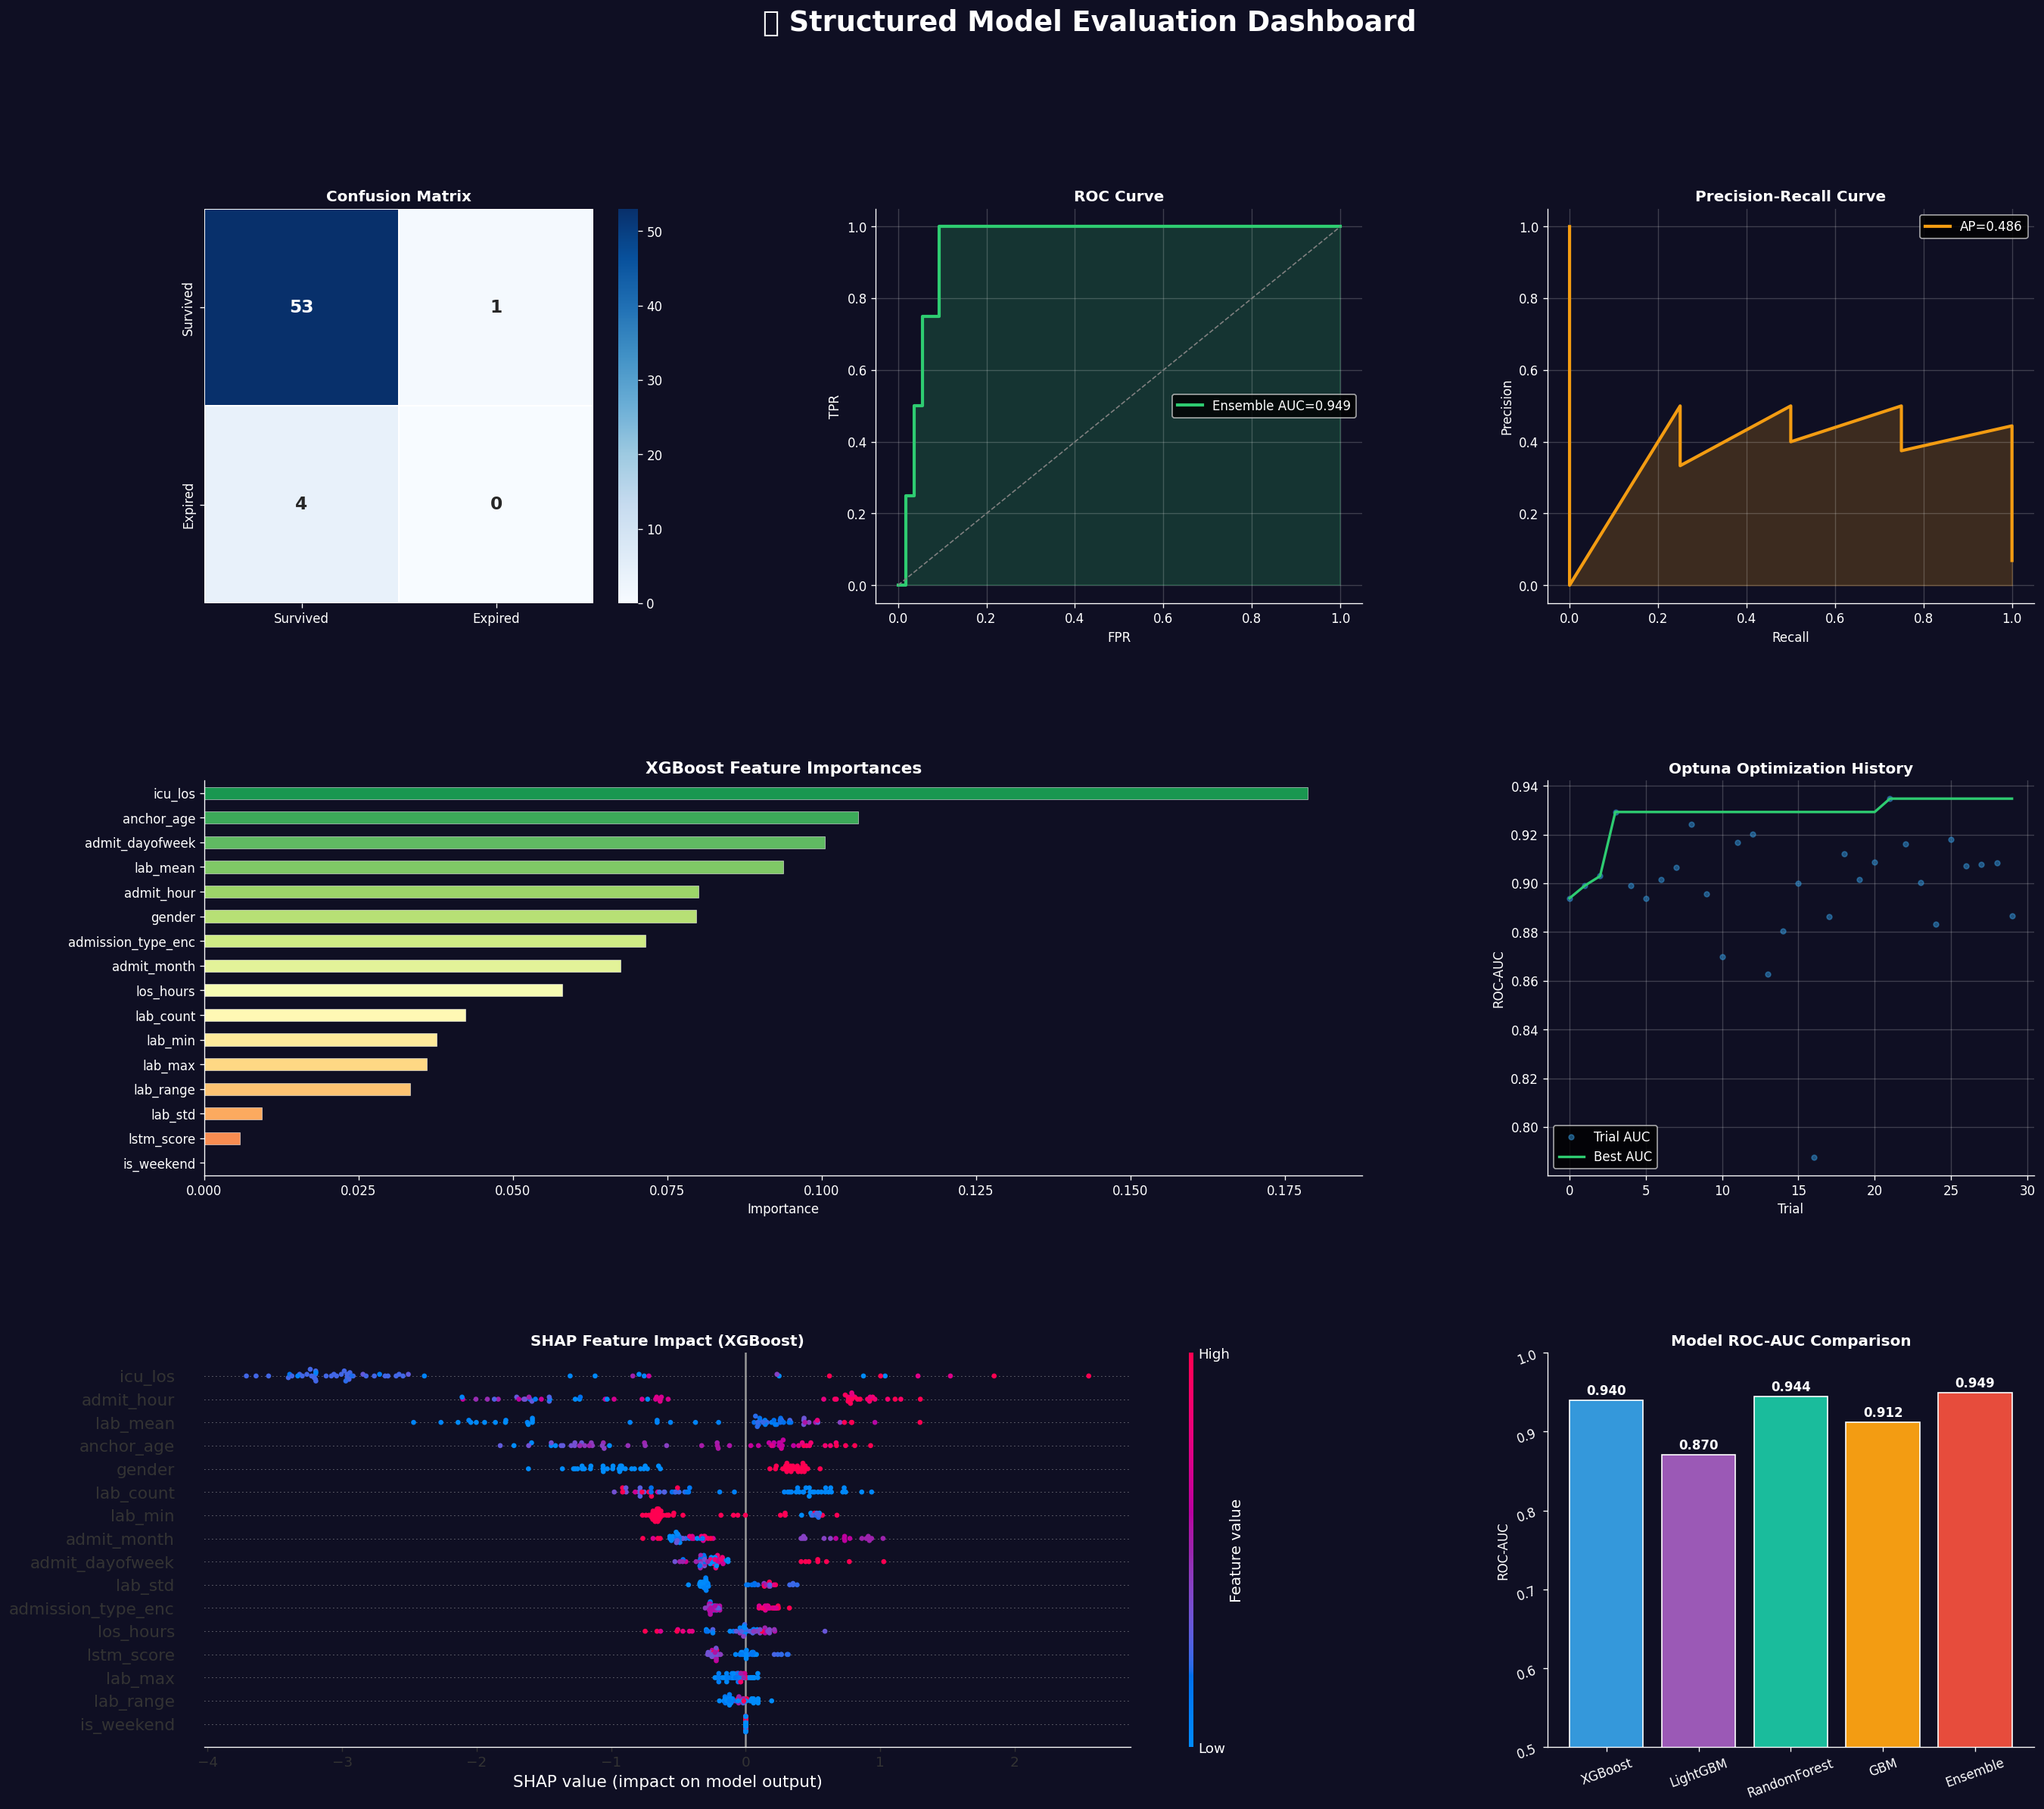

✅ Structured Model Dashboard rendered.


In [31]:
plt.style.use('dark_background')
fig = plt.figure(figsize=(26, 22), facecolor=DARK)
fig.suptitle('🧪 Structured Model Evaluation Dashboard', fontsize=22, color='white', fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# ─── 1. Confusion Matrix ───
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Survived','Expired'],
    yticklabels=['Survived','Expired'],
    ax=ax1, linewidths=1, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
ax1.set_title('Confusion Matrix', color='white', fontweight='bold')
ax1.tick_params(colors='white'); ax1.set_facecolor(DARK)

# ─── 2. ROC Curve ───
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, probs)
auc_val = roc_auc_score(y_test, probs)
ax2.plot(fpr, tpr, color='#2ecc71', linewidth=2.5, label=f'Ensemble AUC={auc_val:.3f}')
ax2.plot([0,1],[0,1],'--', color='gray', linewidth=1)
ax2.fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
ax2.set_xlabel('FPR', color='white'); ax2.set_ylabel('TPR', color='white')
ax2.set_title('ROC Curve', color='white', fontweight='bold')
ax2.legend(); ax2.tick_params(colors='white'); ax2.set_facecolor(DARK)
ax2.grid(True, alpha=0.2)

# ─── 3. PR Curve ───
ax3 = fig.add_subplot(gs[0, 2])
precision_c, recall_c, _ = precision_recall_curve(y_test, probs)
ap = average_precision_score(y_test, probs)
ax3.plot(recall_c, precision_c, color='#f39c12', linewidth=2.5, label=f'AP={ap:.3f}')
ax3.fill_between(recall_c, precision_c, alpha=0.2, color='#f39c12')
ax3.set_xlabel('Recall', color='white'); ax3.set_ylabel('Precision', color='white')
ax3.set_title('Precision-Recall Curve', color='white', fontweight='bold')
ax3.legend(); ax3.tick_params(colors='white'); ax3.set_facecolor(DARK)
ax3.grid(True, alpha=0.2)

# ─── 4. Feature Importance (XGBoost) ───
ax4 = fig.add_subplot(gs[1, 0:2])
feat_names = X_train.columns.tolist()
importances = xgb_best.feature_importances_
fi_df = pd.Series(importances, index=feat_names).sort_values(ascending=True)
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
fi_df.plot(kind='barh', ax=ax4, color=colors_fi, edgecolor='white', linewidth=0.3)
ax4.set_title('XGBoost Feature Importances', color='white', fontweight='bold', fontsize=13)
ax4.set_xlabel('Importance', color='white'); ax4.tick_params(colors='white')
ax4.set_facecolor(DARK)

# ─── 5. Optuna optimization history ───
ax5 = fig.add_subplot(gs[1, 2])
trial_vals = [t.value for t in study.trials if t.value is not None]
running_max = np.maximum.accumulate(trial_vals)
ax5.plot(trial_vals, 'o', color='#3498db', alpha=0.5, markersize=4, label='Trial AUC')
ax5.plot(running_max, '-', color='#2ecc71', linewidth=2, label='Best AUC')
ax5.set_title('Optuna Optimization History', color='white', fontweight='bold')
ax5.set_xlabel('Trial', color='white'); ax5.set_ylabel('ROC-AUC', color='white')
ax5.legend(); ax5.tick_params(colors='white'); ax5.set_facecolor(DARK)
ax5.grid(True, alpha=0.2)

# ─── 6. SHAP Summary ───
ax6 = fig.add_subplot(gs[2, 0:2])
try:
    explainer = shap.TreeExplainer(xgb_best)
    shap_vals = explainer.shap_values(X_test)
    shap.summary_plot(shap_vals, X_test, feature_names=feat_names,
                      show=False, plot_size=None, color_bar=True)
    plt.sca(ax6)
    ax6.set_title('SHAP Feature Impact (XGBoost)', color='white', fontweight='bold')
except Exception as e:
    ax6.text(0.5, 0.5, f'SHAP: {e}', transform=ax6.transAxes, ha='center', color='white')
ax6.set_facecolor(DARK)

# ─── 7. Model comparison bar ───
ax7 = fig.add_subplot(gs[2, 2])
model_names  = ['XGBoost', 'LightGBM', 'RandomForest', 'GBM', 'Ensemble']
individual_aucs = []
for name, clf in [('xgb', xgb_best), ('lgb', lgb_model), ('rf', rf_model), ('gbm', gbm_model)]:
    clf.fit(X_train, y_train)
    p = clf.predict_proba(X_test)[:, 1]
    individual_aucs.append(roc_auc_score(y_test, p))
individual_aucs.append(auc_val)

bar_cols = ['#3498db','#9b59b6','#1abc9c','#f39c12','#e74c3c']
bars7 = ax7.bar(model_names, individual_aucs, color=bar_cols, edgecolor='white')
ax7.bar_label(bars7, fmt='%.3f', color='white', fontweight='bold', padding=2)
ax7.set_title('Model ROC-AUC Comparison', color='white', fontweight='bold')
ax7.set_ylabel('ROC-AUC', color='white'); ax7.set_ylim(0.5, 1.0)
ax7.tick_params(colors='white', rotation=20); ax7.set_facecolor(DARK)

plt.savefig('structured_model_dashboard.png', dpi=120, bbox_inches='tight', facecolor=DARK)
plt.show()
print('✅ Structured Model Dashboard rendered.')

In [32]:
results_df = pd.DataFrame({
    'Case #':              range(1, len(test_cases)+1),
    'Specialty':           case_types,
    'Clinical Note':       query_notes,
    'Ground Truth':        ground_truths,
    'Baseline Answer':     base_answers,
    'RAG Answer':          rag_answers,
    'Predicted Specialty': specialty_preds,
    'NER F1':              [round(f, 3) for f in ner_f1s],
    'Base BERTScore':      [round(f, 3) for f in Base_F1_list],
    'RAG BERTScore':       [round(f, 3) for f in RAG_F1_list],
    'RAG ROUGE-1':         [round(f, 3) for f in rag_r1],
    'RAG ROUGE-2':         [round(f, 3) for f in rag_r2],
    'RAG ROUGE-L':         [round(f, 3) for f in rag_rl],
    'RAG BLEU':            [round(f, 3) for f in rag_bleu],
    'BERTScore Delta':     [round(r-b, 3) for r,b in zip(RAG_F1_list, Base_F1_list)]
})

pd.set_option('display.max_colwidth', 80)
display(results_df[['Case #','Specialty','Predicted Specialty','NER F1',
                     'Base BERTScore','RAG BERTScore','RAG ROUGE-1','BERTScore Delta']].to_string(index=False))

results_df.to_csv('nlp_results.csv', index=False)
print('\n✅ Results saved to nlp_results.csv')

# ── Summary table ──
print('\n' + '='*60)
print('📊 FINAL AGGREGATE SCORES')
print('='*60)
summary = pd.DataFrame({
    'Metric':    ['BERTScore', 'ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BLEU', 'NER F1'],
    'Baseline':  [round(np.mean(Base_F1_list),4), round(np.mean(base_r1),4),
                  round(np.mean(base_r2),4), round(np.mean(base_rl),4),
                  round(np.mean(base_bleu),4), '-'],
    'RAG':       [round(np.mean(RAG_F1_list),4), round(np.mean(rag_r1),4),
                  round(np.mean(rag_r2),4), round(np.mean(rag_rl),4),
                  round(np.mean(rag_bleu),4), round(np.mean(ner_f1s),4)],
})
print(summary.to_string(index=False))
print('='*60)

' Case #          Specialty Predicted Specialty  NER F1  Base BERTScore  RAG BERTScore  RAG ROUGE-1  BERTScore Delta\n      1         Toxicology             General       0           0.672          0.672        0.000            0.000\n      2           Oncology             General       0           0.668          0.671        0.000            0.003\n      3       Rheumatology             General       0           0.708          0.641        0.036           -0.066\n      4         Cardiology             General       0           0.646          0.646        0.000            0.000\n      5         Hematology             General       0           0.645          0.645        0.000            0.000\n      6          Neurology             General       0           0.629          0.628        0.000           -0.000\n      7         Nephrology             General       0           0.711          0.717        0.000            0.006\n      8        Pulmonology             General       0         


✅ Results saved to nlp_results.csv

📊 FINAL AGGREGATE SCORES
   Metric Baseline    RAG
BERTScore   0.6885 0.6776
  ROUGE-1   0.0149 0.0126
  ROUGE-2      0.0 0.0000
  ROUGE-L   0.0149 0.0126
     BLEU   0.0013 0.0020
   NER F1        - 0.0000


In [34]:
# Interactive BERTScore comparison
fig_plotly = go.Figure()
fig_plotly.add_trace(go.Scatter(
    x=list(range(1, 21)), y=Base_F1_list,
    mode='lines+markers', name='Baseline',
    line=dict(color='#e74c3c', width=2),
    marker=dict(size=8),
    text=case_types, hovertemplate='Case %{x}<br>%{text}<br>BERTScore: %{y:.3f}'
))
fig_plotly.add_trace(go.Scatter(
    x=list(range(1, 21)), y=RAG_F1_list,
    mode='lines+markers', name='RAG',
    line=dict(color='#2ecc71', width=2),
    marker=dict(size=8, symbol='square'),
    text=case_types, hovertemplate='Case %{x}<br>%{text}<br>BERTScore: %{y:.3f}'
))
fig_plotly.update_layout(
    title='Interactive BERTScore Comparison: Baseline vs RAG',
    xaxis_title='Case Number', yaxis_title='BERTScore F1',
    template='plotly_dark', height=450
)
fig_plotly.show()

# Sunburst: specialty → metric tier
def tier(score):
    if score >= 0.7: return 'High (≥0.7)'
    elif score >= 0.5: return 'Medium (0.5-0.7)'
    return 'Low (<0.5)'

sunburst_df = pd.DataFrame({
    'specialty': case_types,
    'tier': [tier(f) for f in RAG_F1_list],
    'ner_f1': ner_f1s
})

fig_sun = px.sunburst(
    sunburst_df, path=['specialty', 'tier'],
    color='ner_f1', color_continuous_scale='RdYlGn',
    title='Specialty → BERTScore Tier (Color = NER F1)',
    template='plotly_dark'
)
fig_sun.show()
print('✅ Plotly interactive charts rendered.')

✅ Plotly interactive charts rendered.
